Run 1/50 complete.
Run 2/50 complete.
Run 3/50 complete.
Run 4/50 complete.
Run 5/50 complete.
Run 6/50 complete.
Run 7/50 complete.
Run 8/50 complete.
Run 9/50 complete.
Run 10/50 complete.
Run 11/50 complete.
Run 12/50 complete.
Run 13/50 complete.
Run 14/50 complete.
Run 15/50 complete.
Run 16/50 complete.
Run 17/50 complete.
Run 18/50 complete.
Run 19/50 complete.
Run 20/50 complete.
Run 21/50 complete.
Run 22/50 complete.
Run 23/50 complete.
Run 24/50 complete.
Run 25/50 complete.
Run 26/50 complete.
Run 27/50 complete.
Run 28/50 complete.
Run 29/50 complete.
Run 30/50 complete.
Run 31/50 complete.
Run 32/50 complete.
Run 33/50 complete.
Run 34/50 complete.
Run 35/50 complete.
Run 36/50 complete.
Run 37/50 complete.
Run 38/50 complete.
Run 39/50 complete.
Run 40/50 complete.
Run 41/50 complete.
Run 42/50 complete.
Run 43/50 complete.
Run 44/50 complete.
Run 45/50 complete.
Run 46/50 complete.
Run 47/50 complete.
Run 48/50 complete.
Run 49/50 complete.
Run 50/50 complete.


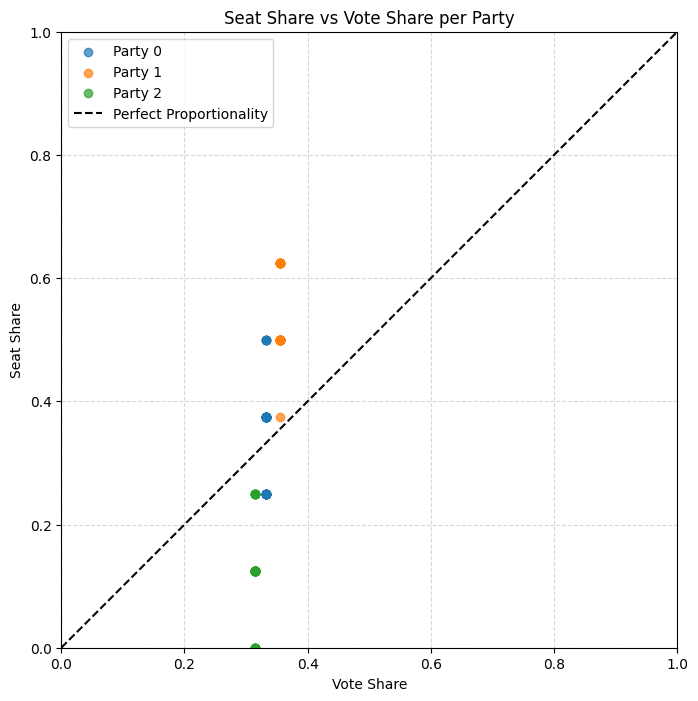


----- REDISTRICTING SUMMARY -----
Runs: 50
Party 0: Mean Vote Share = 0.332, Mean Seat Share = 0.350
Party 1: Mean Vote Share = 0.354, Mean Seat Share = 0.530
Party 2: Mean Vote Share = 0.314, Mean Seat Share = 0.120


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import itertools
import pandas as pd

# ============================================================
# PARAMETERS
# ============================================================
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 2500
NUM_PARTIES = 3
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 50

NUM_CITIES = 6
CITY_INTENSITY = (15, 40)
CITY_SPREAD = (15, 35)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.45, 0.30, 0.25]

# ============================================================
# GENERATE POPULATION DENSITY
# ============================================================
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ============================================================
# GENERATE VOTERS BASED ON DENSITY
# ============================================================
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ============================================================
# SPATIALLY CORRELATED PARTY PREFERENCES
# ============================================================
party_centers = np.column_stack((
    np.random.uniform(0, WIDTH,  NUM_PARTIES),
    np.random.uniform(0, HEIGHT, NUM_PARTIES)
))

voter_parties = np.zeros(NUM_VOTERS, dtype=int)

for i in range(NUM_VOTERS):
    dists   = np.linalg.norm(party_centers - voters[i], axis=1)
    sigma   = 150
    weights = np.exp(-dists**2 / (2 * sigma**2))
    weights = weights * np.array(PARTY_BIAS)
    weights /= weights.sum()
    voter_parties[i] = np.random.choice(NUM_PARTIES, p=weights)

voter_colors = party_colors[voter_parties]

# ============================================================
# DISTRICT GENERATION
# ============================================================

def connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors=15):
    """
    Builds connected districts using BFS from random seeds.
    Retries automatically if a district cannot be completed.
    """
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    for d in range(num_districts):
        if not unassigned:
            break

        seed = list(unassigned)[rng.integers(len(unassigned))]
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)
            neighbors = rng.permutation(neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors)

    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district

# ============================================================
# VOTE COUNTING
# ============================================================

def count_votes(district_labels):
    """Returns a list of vote count dicts, one per district."""
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

# ============================================================
# EFFICIENCY GAP
# ============================================================

def efficiency_gap(district_counts):
    """
    Returns a per-district efficiency gap value (multi-party generalization).
    """
    district_gaps = []
    for district in district_counts:
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]
        total_votes = sum(district.values())
        num_losing_votes = total_votes - num_winning_votes
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes
        gap = (wasted_winner - wasted_loser) / total_votes
        district_gaps.append(gap)
    return district_gaps

# ============================================================
# SEAT-VOTE CURVE HELPERS
# ============================================================

def get_is_winner(district_counts, target_party):
    """Returns True if target_party strictly leads all others."""
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    return all(target_votes > v for v in other_votes)


def get_current_vote_share(district_counts, target_party):
    """Returns the statewide vote share of the target party."""
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total


def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Shifts votes toward target_party by taking from the weakest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p)
            )
            if active_competitors:
                from_party = active_competitors[0]
                actual_taken = min(d[from_party], num_competitors)
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    """
    Shifts votes away from target_party toward the strongest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            to_move = min(d[target_party], num_competitors)
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Builds the full seat-vote step curve for a given party by merging
    forward and backward vote shift histories.
    """
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))

    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    base_point = (initial_vote, initial_wins)
    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged

# ============================================================
# PLOTTING
# ============================================================

def plot_step_and_complement(step_points, NUM_DISTRICTS, title="Seat-Vote Curve"):
    """Plots the seat-vote curve and its complement."""
    x, y = zip(*sorted(step_points))
    x, y = np.array(x), np.array(y)
    y = y / NUM_DISTRICTS

    plt.figure(figsize=(8, 6))
    plt.step(x, y, where="post", color="black", label="Seat-Vote Curve", lw=2)

    xc = 1 - x
    yc = 1 - y
    order = np.argsort(xc)
    plt.step(xc[order], yc[order], where="post",
             color="blue", linestyle="--", label="Complement Curve")

    plt.xlabel("Statewide Vote Share")
    plt.ylabel("Seat Share")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()

# ============================================================
# AREA METRICS
# ============================================================

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat-vote curve and its complement.
    Returns dict with keys: area_between, area_step, area_complement
    """
    points = sorted(step_points, key=lambda x: x[0])

    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]

    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts

    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]

    all_x = np.unique(np.concatenate([step_x, complement_x]))

    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    for i in range(len(all_x) - 1):
        x1, x2 = all_x[i], all_x[i + 1]
        width = x2 - x1
        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)
        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }


def compute_pairwise_area(curve1, curve2, num_districts):
    """
    Computes the absolute area between the step curves of two parties.
    Integral of |f(x) - g(x)| dx over [0, 1].
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))

    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0:
        all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1:
        all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff

    return total_area

# ============================================================
# EXCEL EXPORT
# ============================================================

def export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS,
                                 filename="gerrymandering_data.xlsx"):
    """
    Exports simulation results to Excel with four sheets:
      - District_Details: per-district vote counts and winners
      - Pairwise_Areas:   area gap between each party pair per run
      - Efficiency_Gaps:  efficiency gap per party per run
      - Summary:          mean and std of pairwise areas
    """
    print(f"Gathering data for {len(all_district_counts)} runs...")

    dist_rows = []
    for run_idx, run_counts in enumerate(all_district_counts):
        for dist_idx, counts in enumerate(run_counts):
            winner = max(counts, key=counts.get)
            row = {"Run": run_idx + 1, "District": dist_idx + 1, "Winner": winner}
            for party in PARTY_IDS:
                row[f"{party}_Votes"] = counts[party]
            dist_rows.append(row)
    df_districts = pd.DataFrame(dist_rows)

    pair_rows = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
            pair_rows.append({"Run": run_idx + 1, "Comparison": f"{p1} vs {p2}", "Area_Gap": gap})
    df_areas = pd.DataFrame(pair_rows)

    gap_rows = []
    for run_idx, district_counts in enumerate(all_district_counts):
        wasted_votes = {p: 0 for p in PARTY_IDS}
        total_v = 0
        for d in district_counts:
            d_total = sum(d.values())
            total_v += d_total
            sorted_v = sorted(d.values(), reverse=True)
            winner_p = max(d, key=d.get)
            needed = sorted_v[1] + 1 if len(sorted_v) > 1 else (d_total // 2) + 1
            for p in PARTY_IDS:
                wasted_votes[p] += (max(0, d[p] - needed) if p == winner_p else d[p])
        for p in PARTY_IDS:
            others = sum(v for k, v in wasted_votes.items() if k != p)
            gap_rows.append({
                "Run": run_idx + 1,
                "Party": p,
                "Eff_Gap": (wasted_votes[p] - others) / total_v
            })
    df_eff = pd.DataFrame(gap_rows)

    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_districts.to_excel(writer, sheet_name='District_Details', index=False)
        df_areas.to_excel(writer, sheet_name='Pairwise_Areas', index=False)
        df_eff.to_excel(writer, sheet_name='Efficiency_Gaps', index=False)
        summary = df_areas.groupby("Comparison")["Area_Gap"].agg(['mean', 'std']).reset_index()
        summary.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Export Complete: {filename}")

# ============================================================
# MAIN SIMULATION
# ============================================================

all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []
all_seat_shares = []
all_pr_vote_shares = []
all_pr_seat_shares = []
all_district_counts = []
all_area_results = []
all_step_curves = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng()

    district_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng
    )
    district_counts = count_votes(district_labels)

    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)

    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts, party, PARTY_IDS, NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_results_this_run[party] = compute_step_function_area(curve, NUM_DISTRICTS)

    all_step_curves.append(step_curves_this_run)
    all_area_results.append(area_results_this_run)

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ============================================================
# SCATTER PLOT: Vote Share vs Seat Share
# ============================================================

plt.figure(figsize=(8, 8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")

In [31]:
# ------------------------------------------------------------
# RUN PAIRWISE SIMULATIONS
# ------------------------------------------------------------
pairwise_results = []
party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run_idx in range(NUM_RUNS):
    # (Assuming district_counts and curves are generated here as in your main code)
    # Get all party curves for this run
    current_curves = all_step_curves[run_idx] 
    
    for p1, p2 in party_pairs:
        area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
        
        pairwise_results.append({
            "Run": run_idx + 1,
            "Comparison": f"{p1} vs {p2}",
            "Area Gap": area_gap
        })

df_pairs = pd.DataFrame(pairwise_results)
print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairs.head(20).to_string(index=False))



--- PAIRWISE AREA DIFFERENCES ---
 Run         Comparison  Area Gap
   1 Party 0 vs Party 1   0.04610
   1 Party 0 vs Party 2   0.04225
   1 Party 1 vs Party 2   0.02775
   2 Party 0 vs Party 1   0.06240
   2 Party 0 vs Party 2   0.06760
   2 Party 1 vs Party 2   0.05330
   3 Party 0 vs Party 1   0.05920
   3 Party 0 vs Party 2   0.05075
   3 Party 1 vs Party 2   0.04785
   4 Party 0 vs Party 1   0.05275
   4 Party 0 vs Party 2   0.05435
   4 Party 1 vs Party 2   0.04850
   5 Party 0 vs Party 1   0.04235
   5 Party 0 vs Party 2   0.06950
   5 Party 1 vs Party 2   0.03235
   6 Party 0 vs Party 1   0.06435
   6 Party 0 vs Party 2   0.04230
   6 Party 1 vs Party 2   0.04935
   7 Party 0 vs Party 1   0.04300
   7 Party 0 vs Party 2   0.03645


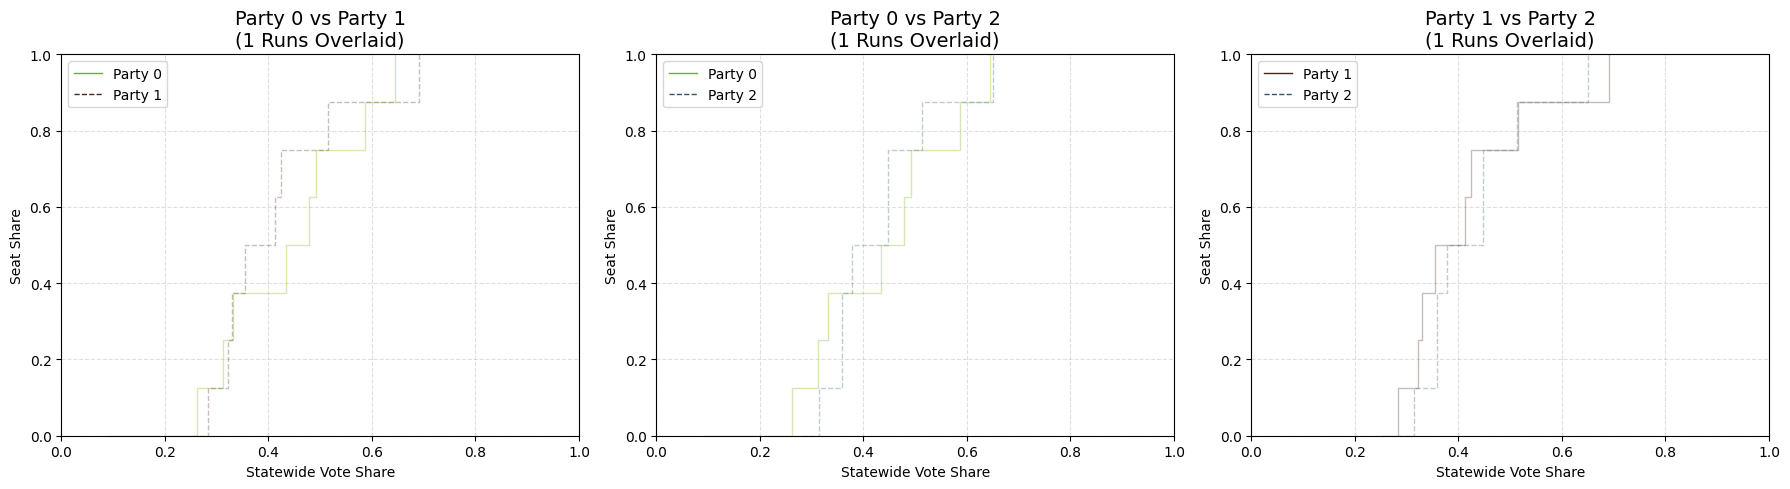

In [32]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=20):
    """
    Creates one graph for each unique party pair.
    Each graph overlays multiple simulation runs to show the variance in bias.
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs = len(party_pairs)
    
    # Create a grid: 1 row, N columns (one for each pair)
    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)
    
    # Determine how many runs to overlay
    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]
        
        for run_idx in range(runs_to_show):
            # Extract curves
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]
            
            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))
            
            # Normalize to Seat Share
            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS
            
            # Use alpha (transparency) to handle the "overlay" effect
            # Only add a label for the first run so the legend isn't huge
            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None
            
            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a], 
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b], 
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        # Formatting
        ax.set_title(f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)", fontsize=14)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Legend with opaque lines for clarity
        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles: 
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=1)


--- PAIRWISE AREA DIFFERENCES ---
        Comparison  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10  Run 11  Run 12  Run 13  Run 14  Run 15  Run 16  Run 17  Run 18  Run 19  Run 20  Run 21  Run 22  Run 23  Run 24  Run 25  Run 26  Run 27  Run 28  Run 29  Run 30  Run 31  Run 32  Run 33  Run 34  Run 35  Run 36  Run 37  Run 38  Run 39  Run 40  Run 41  Run 42  Run 43  Run 44  Run 45  Run 46  Run 47  Run 48  Run 49  Run 50   Mean  Std Dev
Party 0 vs Party 1 0.0461 0.0624 0.0592 0.0527 0.0423 0.0643 0.0430 0.0595 0.0600  0.0438  0.0572  0.0461  0.0552  0.0527  0.0326  0.0638  0.0749  0.0540  0.0455  0.0635  0.0399  0.0533  0.0558  0.0351  0.0398  0.0534  0.0452  0.0271  0.0374  0.0454  0.0682  0.0614  0.0561  0.0439  0.0326  0.0595  0.0445  0.0582  0.0523  0.0644  0.0361  0.0361  0.0360  0.0602  0.0500  0.0495  0.0462  0.0534  0.0391  0.0430 0.0500   0.0105
Party 0 vs Party 2 0.0423 0.0676 0.0507 0.0544 0.0695 0.0423 0.0365 0.0528 0.0557  0.0613  0.0475  0.0562  0.0788

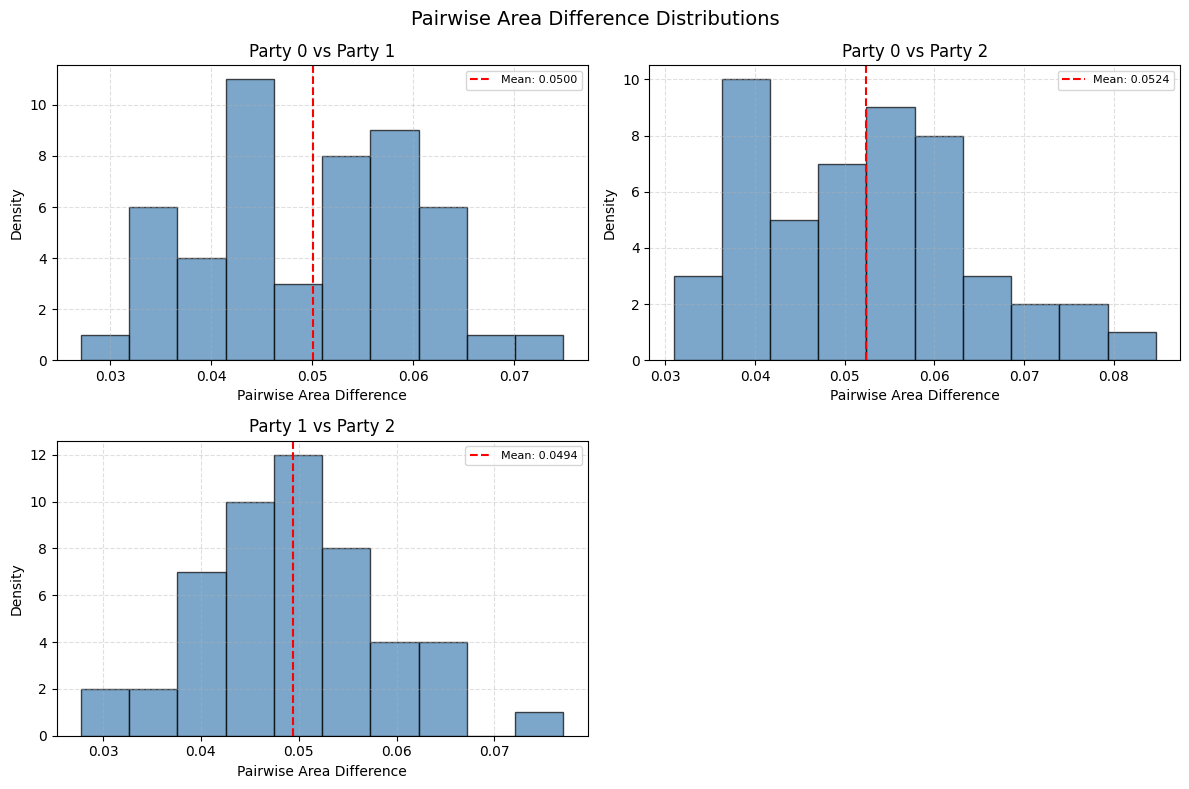

In [33]:
# ------------------------------------------------------------
# PAIRWISE AREA DIFFERENCE TABLE
# ------------------------------------------------------------
import math
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
party_pairs = list(itertools.combinations(PARTY_IDS, 2))
pairwise_matrix = []
pair_labels = []

for p1, p2 in party_pairs:
    pair_label = f"{p1} vs {p2}"
    pair_labels.append(pair_label)
    pair_row = []
    for run_idx in range(len(all_area_results)):
        area = compute_pairwise_area(
            all_step_curves[run_idx][p1],
            all_step_curves[run_idx][p2],
            NUM_DISTRICTS
        )
        pair_row.append(area)
    pairwise_matrix.append(pair_row)

df_pairwise = pd.DataFrame(
    pairwise_matrix,
    columns=[f"Run {i+1}" for i in range(len(all_area_results))]
)
df_pairwise["Mean"] = df_pairwise.mean(axis=1)
df_pairwise["Std Dev"] = df_pairwise.std(axis=1)
df_pairwise.insert(0, "Comparison", pair_labels)

print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairwise.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# PAIRWISE HISTOGRAM
# ------------------------------------------------------------

n_pairs = len(party_pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() if n_pairs > 1 else [axes]

for i, (p1, p2) in enumerate(party_pairs):
    data = list(df_pairwise.iloc[i, 1:len(all_area_results)+1])
    mean_val = np.mean(data)

    axes[i].hist(data, bins=min(10, len(data)), alpha=0.7,
                 color='steelblue', edgecolor='black', density=False)
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {mean_val:.4f}")
    axes[i].set_title(f"{p1} vs {p2}", fontsize=12)
    axes[i].set_xlabel("Pairwise Area Difference")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Pairwise Area Difference Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
def print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS):
    """
    Prints a detailed election breakdown for each run including:
      - District-level vote counts and winner
      - Total seats won per party
      - Statewide vote share per party
    """
    for run_idx, district_counts in enumerate(all_district_counts):
        print(f"\n{'='*60}")
        print(f"  RUN {run_idx + 1}")
        print(f"{'='*60}")

        # District breakdown
        print(f"\n  {'District':<12} {'Winner':<12}", end="")
        for party in PARTY_IDS:
            print(f" {party:>12}", end="")
        print(f" {'Total':>10}")
        print(f"  {'-'*12} {'-'*12}", end="")
        for _ in PARTY_IDS:
            print(f" {'-'*12}", end="")
        print(f" {'-'*10}")

        for d_idx, counts in enumerate(district_counts):
            winner = max(counts, key=counts.get)
            total = sum(counts.values())
            print(f"  {'District '+str(d_idx+1):<12} {winner:<12}", end="")
            for party in PARTY_IDS:
                print(f" {counts[party]:>12}", end="")
            print(f" {total:>10}")

        # Seats won per party
        seats = {party: 0 for party in PARTY_IDS}
        for counts in district_counts:
            winner = max(counts, key=counts.get)
            seats[winner] += 1

        print(f"\n  {'--- Seats Won ---'}")
        for party in PARTY_IDS:
            bar = "█" * seats[party]
            print(f"  {party:<12}: {seats[party]:>2} seats  {bar}")

        # Statewide vote share
        print(f"\n  {'--- Statewide Vote Share ---'}")
        for party in PARTY_IDS:
            vote_share = all_pr_vote_shares[run_idx][party]
            seat_share = all_pr_seat_shares[run_idx][party]
            print(f"  {party:<12}: Vote {vote_share:.3f}  |  Seat Share {seat_share:.3f}")

    print(f"\n{'='*60}")
    print("  END OF RESULTS")
    print(f"{'='*60}\n")


# ── USAGE — call this after the simulation loop ──
print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS)


  RUN 1

  District     Winner            Party 0      Party 1      Party 2      Total
  ------------ ------------ ------------ ------------ ------------ ----------
  District 1   Party 0               115           94          103        312
  District 2   Party 1                65          144          103        312
  District 3   Party 1                81          126          107        314
  District 4   Party 1                60          157           95        312
  District 5   Party 0               208           52           52        312
  District 6   Party 0               134           85           93        312
  District 7   Party 2                89          103          120        312
  District 8   Party 1                77          125          112        314

  --- Seats Won ---
  Party 0     :  3 seats  ███
  Party 1     :  4 seats  ████
  Party 2     :  1 seats  █

  --- Statewide Vote Share ---
  Party 0     : Vote 0.332  |  Seat Share 0.375
  Party 1     : Vote


--- FAIR: EFFICIENCY GAP ---
 Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted  Party 2_Wasted
   1          0.0112          0.2312          0.1860          0.2724
   2          0.0343          0.1844          0.1816          0.3140
   3          0.0100          0.2352          0.1872          0.2684
   4          0.0106          0.2284          0.1840          0.2680
   5          0.0346          0.1836          0.1812          0.3140
   6          0.0122          0.2736          0.1836          0.2320
   7          0.0115          0.2736          0.1860          0.2272
   8          0.0111          0.2300          0.1836          0.2696
   9          0.0471          0.2280          0.1368          0.3140
  10          0.0124          0.2284          0.1816          0.2724
  11          0.0339          0.2720          0.1412          0.2708
  12          0.0116          0.2296          0.1844          0.2724
  13          0.0346          0.1852          0.1800          0.3140
  14

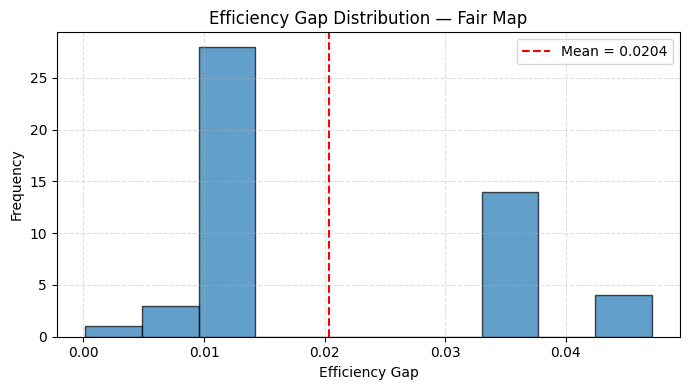

In [35]:
# ============================================================
# MULTI-PARTY EFFICIENCY GAP — SUM OF SQUARED DIFFERENCES
# ============================================================
def compute_efficiency_gap_table(all_district_counts, label=""):

    gap_rows = []

    for run_idx in range(len(all_district_counts)):
        district_counts = all_district_counts[run_idx]

        wasted_votes = {party: 0 for party in PARTY_IDS}
        total_votes  = 0

        for district in district_counts:
            district_total  = sum(district.values())
            total_votes    += district_total

            sorted_parties  = sorted(district.items(), key=lambda x: x[1], reverse=True)
            winner, _       = sorted_parties[0]
            runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
            needed_to_win   = runner_up_votes + 1

            for party in PARTY_IDS:
                votes = district[party]
                if party == winner:
                    wasted_votes[party] += max(0, votes - needed_to_win)
                else:
                    wasted_votes[party] += votes

        w = {party: wasted_votes[party] / total_votes for party in PARTY_IDS}

        squared_diff_sum = 0.0
        for p1, p2 in itertools.combinations(PARTY_IDS, 2):
            squared_diff_sum += (w[p1] - w[p2]) ** 2

        gap_rows.append({
            "Run":            run_idx + 1,
            "Efficiency_Gap": squared_diff_sum,
            **{f"{party}_Wasted": w[party] for party in PARTY_IDS}
        })

    df_gap = pd.DataFrame(gap_rows)

    print(f"\n--- {label}: EFFICIENCY GAP ---")
    print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"\nMean Efficiency Gap: {df_gap['Efficiency_Gap'].mean():.4f}")
    print(f"Std  Efficiency Gap: {df_gap['Efficiency_Gap'].std():.4f}")

    return df_gap

df_gap = compute_efficiency_gap_table(all_district_counts, label="FAIR")

# ── Histogram ─────────────────────────────────────────────
data     = df_gap["Efficiency_Gap"].values
mean_val = np.mean(data)

plt.figure(figsize=(7, 4))
plt.hist(data, bins=10, alpha=0.7, edgecolor="black")
plt.axvline(mean_val, color="red", linestyle="--",
            label=f"Mean = {mean_val:.4f}")
plt.title("Efficiency Gap Distribution — Fair Map")
plt.xlabel("Efficiency Gap")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

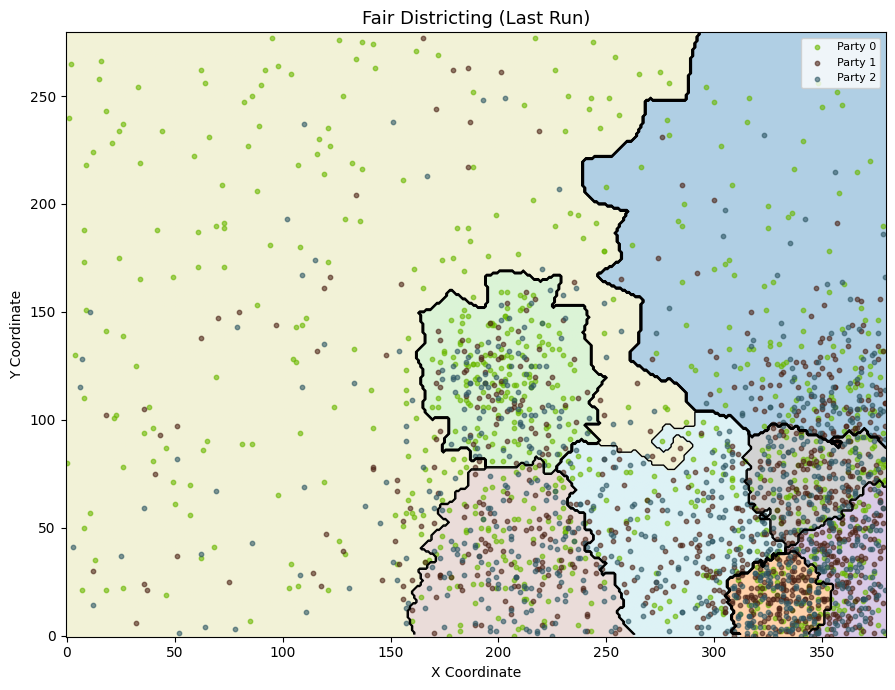

In [36]:

# ============================================================
# VISUALIZATION
# ============================================================
def plot_districts(district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))
    _, nearest_voter = tree.query(grid_points)
    pixel_map = district_labels[nearest_voter].reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(pixel_map, levels=np.arange(NUM_DISTRICTS) + 0.5,
                colors='black', linewidths=1, origin='lower')
    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(voters[mask, 0], voters[mask, 1],
                    color=PARTY_COLORS[party], label=party, s=10, alpha=0.6)
    plt.title(title, fontsize=13)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================================
# VISUALIZE LAST RUN
# ============================================================
plot_districts(district_labels, voter_parties, "Fair Districting (Last Run)")